# 7.4 Geostatistical Interpolation

**Part:** 7 — Spatial Interpolation (Chapter 7.4 of 8)

**Dataset:** `meuse.csv` (155 topsoil samples, Meuse floodplain, EPSG:28992) predicted onto `meuse_grid.csv` (3,103 cells, 40 m). Kriging uses log(zinc).

**Focus:** the semivariogram; ordinary kriging; prediction variance; calibration; agreement with `pykrige`

**Library:** `spatialstats.interpolate` (PySpatialStats)


***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [The Semivariogram](#3.-The-Semivariogram)
4.. [Empirical and Fitted Variograms](#4.-Empirical-and-Fitted-Variograms)
5.. [Ordinary Kriging](#5.-Ordinary-Kriging)
6.. [The Kriging Prediction Variance](#6.-The-Kriging-Prediction-Variance)
7.. [Calibration: Standardized LOO Errors](#7.-Calibration:-Standardized-LOO-Errors)
8.. [Agreement with pykrige](#8.-Agreement-with-pykrige)
9.. [Summary and Conclusions](#9.-Summary-and-Conclusions)
10.. [Resources](#10.-Resources)

***
## 1. Overview

This chapter delivers on Chapter 7.1's promise: a method whose predictions come with an honest, checkable
measure of confidence, derived from an explicit model of the field's spatial correlation rather than from
distance alone.

Chapter 7.3 interpolated zinc in ppm. Zinc on this floodplain is strongly right-skewed (113 to 1,839 ppm), so
the kriging here is done on $\log(\mathrm{zinc})$, the scale on which a constant-mean model is plausible.
Coordinates are already in metres (Amersfoort / RD New, EPSG:28992). Predictions are made at the cell centres
in `meuse_grid.csv`, the same 40 m floodplain lattice as in Chapter 7.3.

| Step | What we do |
|------|------------|
| Theory | The semivariogram $\gamma(h)$; nugget, partial sill, range; three common models |
| Fit | `empirical_variogram`, `fit_variogram`, `fit_variogram_auto` on the 155 Meuse samples |
| Krige | `OrdinaryKriging` — the BLUP under an unknown constant mean |
| Trust it | The kriging variance, and a calibration check confirming it is not just a number but a *correct* one |
| Cross-check | Agreement with the independent, widely used `pykrige` package |


***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import empirical_variogram, fit_variogram, fit_variogram_auto, VariogramModel, OrdinaryKriging

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

meuse = pd.read_csv(DATA / "meuse.csv")
grid = pd.read_csv(DATA / "meuse_grid.csv")
coords = meuse[["x", "y"]].to_numpy(dtype=float)
zinc = meuse["zinc"].to_numpy(dtype=float)
values = np.log(zinc)
grid_xy = grid[["x", "y"]].to_numpy(dtype=float)

_xs = np.sort(grid["x"].unique())
_ys = np.sort(grid["y"].unique())
_dx, _dy = float(_xs[1] - _xs[0]), float(_ys[1] - _ys[0])
EXTENT = (_xs[0] - _dx / 2, _xs[-1] + _dx / 2, _ys[0] - _dy / 2, _ys[-1] + _dy / 2)


def to_raster(pred) -> np.ndarray:
    """Place predictions for the meuse_grid cells on the 40 m lattice (NaN off the floodplain)."""
    raster = np.full((len(_ys), len(_xs)), np.nan)
    raster[np.searchsorted(_ys, grid_xy[:, 1]), np.searchsorted(_xs, grid_xy[:, 0])] = pred
    return raster


print(f"spatialstats : version {spatialstats.__version__}")
print(f"n = {len(coords)} samples, {len(grid_xy)} prediction cells at {_dx:.0f} m")
print(f"zinc: {zinc.min():.0f} to {zinc.max():.0f} ppm; log(zinc): {values.min():.2f} to {values.max():.2f}")


spatialstats : version 0.2.0
n = 155 samples, 3103 prediction cells at 40 m
zinc: 113 to 1839 ppm; log(zinc): 4.73 to 7.52


***
## 3. The Semivariogram

$$
\gamma(h) = \tfrac{1}{2}\,\mathrm{Var}\!\left[Z(\mathbf{s}+h) - Z(\mathbf{s})\right] = C(0) - C(h)
$$

$\gamma(h)$ measures how *dissimilar* two observations typically are as a function of the distance $h$ between
them, under second-order stationarity (Chapter 7.1, Section 4). Three parameters describe a fitted variogram
model:

- **nugget** ($C_0$): dissimilarity that persists even at $h \to 0$ — measurement error plus any spatial
  structure finer than the sampling network can resolve.
- **partial sill** ($C$): the additional variance explained by spatial correlation, on top of the nugget.
- **range**: the distance beyond which $\gamma(h)$ flattens out — pairs farther apart than the range are
  (approximately) spatially uncorrelated. This library reports the **practical range** for the exponential and
  Gaussian models (where $\gamma(h)$ only asymptotes, never truly flattens): the distance at which 95% of the
  sill is reached.

Three common models, each with a different rate of approach to the sill:

$$
\gamma_{\text{spherical}}(h) = C_0 + C\left[\tfrac{3h}{2a} - \tfrac{1}{2}\left(\tfrac{h}{a}\right)^3\right] \;(h \le a), \quad
\gamma_{\text{exponential}}(h) = C_0 + C\left[1 - e^{-h/a}\right], \quad
\gamma_{\text{gaussian}}(h) = C_0 + C\left[1 - e^{-(h/a)^2}\right]
$$

***
## 4. Empirical and Fitted Variograms

`empirical_variogram` bins observation pairs by distance (Matheron's method-of-moments estimator) into
`n_lags` lags; `fit_variogram` fits a chosen model to those bins by Cressie-weighted least squares (down-weighting
noisy, sparsely populated far lags); `fit_variogram_auto` tries several models and returns the best one by fit
quality.

In [2]:
empirical = empirical_variogram(coords, values, n_lags=15)
print(empirical.head(8))

vm_auto, empirical_auto = fit_variogram_auto(coords, values, models=("spherical", "exponential", "gaussian"))
print(f"\nauto-selected model: {vm_auto.model}")
print(f"nugget={vm_auto.nugget:.3f}   partial sill={vm_auto.psill:.3f}   range={vm_auto.range:,.0f} m")


           lag     gamma  n_pairs
0   112.027584  0.149697      158
1   226.807778  0.272436      518
2   372.695422  0.382132      659
3   515.797630  0.518178      722
4   665.862112  0.580283      799
5   813.100442  0.622774      803
6   960.810149  0.678342      779
7  1109.813743  0.676410      714

auto-selected model: spherical
nugget=0.033   partial sill=0.570   range=807 m


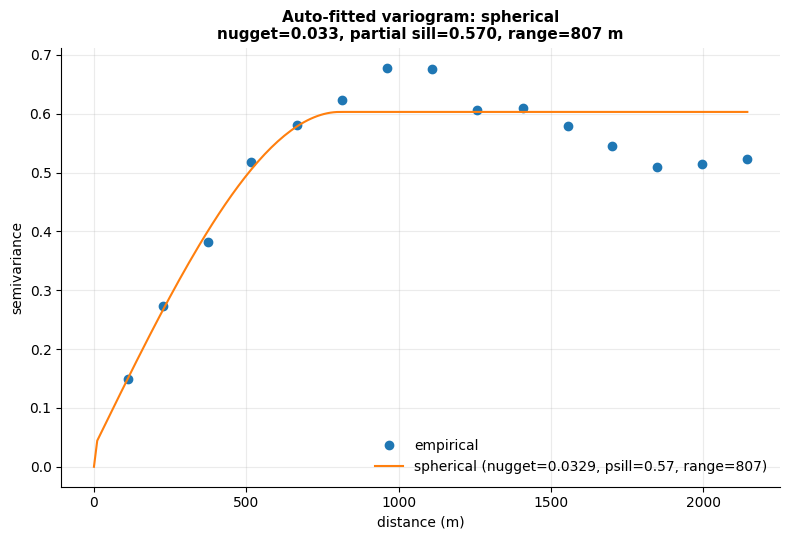

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
vm_auto.plot(empirical, ax=ax)
ax.set_title(f"Auto-fitted variogram: {vm_auto.model}\n"
            f"nugget={vm_auto.nugget:.3f}, partial sill={vm_auto.psill:.3f}, range={vm_auto.range:.0f} m")
ax.set_xlabel("distance (m)")
plt.tight_layout()
plt.savefig("variogram_fit.png", dpi=100, bbox_inches="tight")
plt.show()


The auto-fitted model is **spherical**, with a nugget of about 0.033, a partial sill of about 0.57, and a
practical range of about 810 m. The nugget is much smaller than the partial sill, so most of the variance in
log zinc is spatially structured rather than measurement noise or variation finer than the sample spacing.
Samples more than about 800 m apart are essentially uninformative about each other. The floodplain is a few
kilometres long, so that range covers a neighbourhood, not the whole map.

***
## 5. Ordinary Kriging

Ordinary kriging predicts as a weighted average $\hat{Z}(\mathbf{s}_0) = \sum_i \lambda_i Z(\mathbf{s}_i)$, with
weights $\boldsymbol{\lambda}$ solved from the variogram under the constraint $\sum_i \lambda_i = 1$ (so the
predictor is unbiased without needing to know the field's true mean in advance). Because the weights come from
the *variogram*, not raw distance, **clustered samples are automatically down-weighted** relative to isolated
ones carrying unique information — something IDW's purely distance-based weights cannot do.


In [4]:
ok = OrdinaryKriging(variogram="auto")
ok.fit(coords, values)
print(f"fitted variogram: {ok.variogram_.model}, nugget={ok.variogram_.nugget:.3f}, "
      f"psill={ok.variogram_.psill:.3f}, range={ok.variogram_.range:,.0f} m")

pred_at_data, std_at_data = ok.predict(coords, return_std=True)
print(f"exact at data points: max |pred - observed| = {np.max(np.abs(pred_at_data - values)):.2e}")

fitted variogram: spherical, nugget=0.033, psill=0.570, range=807 m
exact at data points: max |pred - observed| = 1.69e-14


Because $\gamma(0) = 0$ in the kriging system, ordinary kriging reproduces every sample exactly — confirmed
above to machine precision — even though the fitted nugget is positive. The nugget is the jump in $\gamma(h)$
as $h \to 0$, not a noise term placed on the diagonal.

***
## 6. The Kriging Prediction Variance


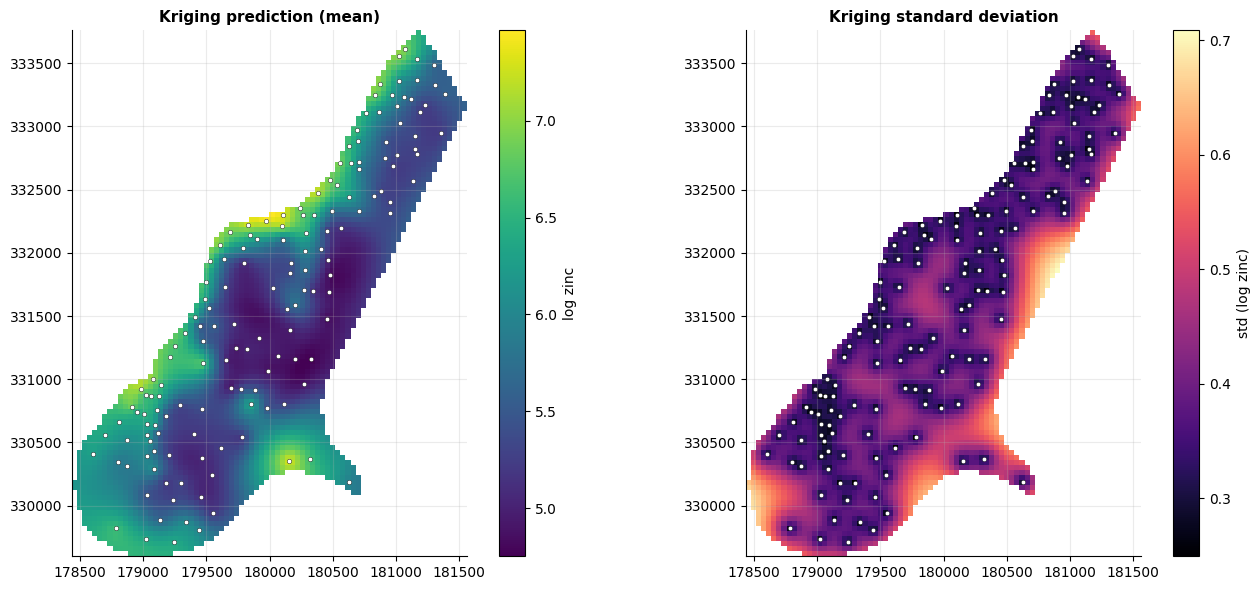

prediction range: 4.75 to 7.47
kriging std range on the grid: 0.25 to 0.71


In [5]:
pred_grid, std_grid = ok.predict(grid_xy, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(to_raster(pred_grid), extent=EXTENT, origin="lower", cmap="viridis")
axes[0].scatter(coords[:, 0], coords[:, 1], s=10, color="white", edgecolor="k", linewidth=0.3)
axes[0].set_title("Kriging prediction (mean)")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="log zinc")

im1 = axes[1].imshow(to_raster(std_grid), extent=EXTENT, origin="lower", cmap="magma")
axes[1].scatter(coords[:, 0], coords[:, 1], s=10, color="white", edgecolor="k", linewidth=0.3)
axes[1].set_title("Kriging standard deviation")
axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="std (log zinc)")
plt.tight_layout()
plt.savefig("kriging_mean_variance.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"prediction range: {pred_grid.min():.2f} to {pred_grid.max():.2f}")
print(f"kriging std range on the grid: {std_grid.min():.2f} to {std_grid.max():.2f}")


The standard-deviation map is the payoff Chapter 7.1 promised: **low near the samples, higher in the gaps**
of the floodplain — visibly independent of the log-zinc surface, and entirely a function of the sampling
geometry and the variogram. On the 40 m grid the standard deviation runs from about 0.25, beside a sample, to
about 0.71 at the least-supported cells. It is zero only at the samples themselves. This is not something any
of Chapter 7.3's deterministic methods can produce, because none of them has an explicit model of spatial
correlation to draw it from.

***
## 7. Calibration: Standardized LOO Errors

A prediction variance is only useful if it is **correctly calibrated** — if the true error, divided by the
predicted standard deviation, behaves like a standard normal variable. Leave-one-out is the natural check: hold
out each sample, krige it from the rest, and standardize.


standardized LOO error: mean=-0.000, sd=0.948
fraction within +-1.96 (nominal 95%): 95.5%


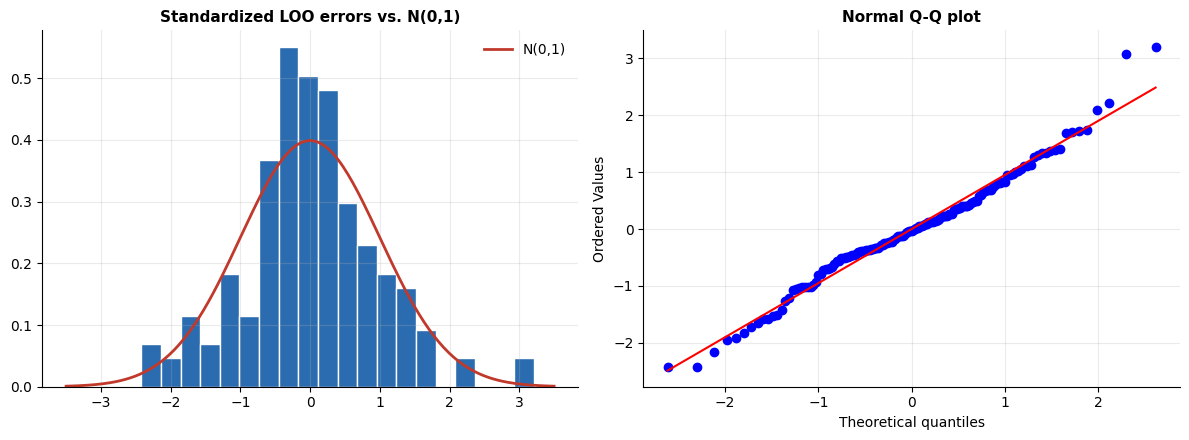

In [6]:
n = len(coords)
std_errors = np.empty(n)
for i in range(n):
    mask = np.ones(n, dtype=bool)
    mask[i] = False
    m = OrdinaryKriging(variogram="auto")
    m.fit(coords[mask], values[mask])
    pred_i, std_i = m.predict(coords[i:i + 1], return_std=True)
    std_errors[i] = (values[i] - pred_i[0]) / std_i[0]

print(f"standardized LOO error: mean={std_errors.mean():.3f}, sd={std_errors.std():.3f}")
print(f"fraction within +-1.96 (nominal 95%): {(np.abs(std_errors) < 1.96).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(std_errors, bins=20, color=COLORS["blue"], edgecolor="white", density=True)
xs = np.linspace(-3.5, 3.5, 200)
axes[0].plot(xs, stats.norm.pdf(xs), color=COLORS["red"], linewidth=2, label="N(0,1)")
axes[0].set_title("Standardized LOO errors vs. N(0,1)")
axes[0].legend()
stats.probplot(std_errors, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout()
plt.savefig("kriging_calibration.png", dpi=100, bbox_inches="tight")
plt.show()

Mean essentially 0 and standard deviation about 0.95, with about 95% of standardized errors inside $\pm 1.96$ —
this is a genuinely calibrated uncertainty estimate on the log-zinc scale, not just a number that happens to
be called "variance." Chapter 7.5's cross-validation extends this same idea (held-out prediction accuracy) to
every method in this Part, not just kriging's own calibration.

***
## 8. Agreement with pykrige

As an independent correctness check, `pykrige` — a widely used, separately implemented kriging package — should
agree with this library's own kriging system exactly, once fed the identical variogram parameters. One
important gotcha: **`pykrige` takes the *total* sill** (nugget + partial sill), not the partial sill this
library reports separately. The check below predicts at a sample of `meuse_grid.csv` cell centres.


In [7]:
from pykrige.ok import OrdinaryKriging as PyKrigeOK

vg = ok.variogram_
pk = PyKrigeOK(coords[:, 0], coords[:, 1], values, variogram_model="spherical",
              variogram_parameters={"nugget": vg.nugget, "sill": vg.nugget + vg.psill, "range": vg.range})

rng = np.random.RandomState(0)
test_pts = grid_xy[rng.choice(len(grid_xy), 20, replace=False)]

pred_ours = ok.predict(test_pts)
pred_pk, _ = pk.execute("points", test_pts[:, 0], test_pts[:, 1])
pred_pk = np.asarray(pred_pk).ravel()

print(f"max |ours - pykrige|: {np.max(np.abs(pred_ours - pred_pk)):.2e}")
print(f"ours   : {pred_ours[:5]}")
print(f"pykrige: {pred_pk[:5]}")


max |ours - pykrige|: 1.20e-13
ours   : [5.32580672 4.89096774 6.05453787 5.35674574 5.18858733]
pykrige: [5.32580672 4.89096774 6.05453787 5.35674574 5.18858733]


Agreement to machine precision confirms this library's kriging implementation is solving the same linear system
`pykrige` does, not merely producing plausible-looking numbers — a genuine, independent correctness check on
the core method this whole chapter relies on.

***
## 9. Summary and Conclusions

This chapter introduced the semivariogram, fit it to log zinc on the Meuse floodplain, kriged onto
`meuse_grid.csv`, and checked the result two different ways: statistical calibration and independent-package
agreement.

### What we did

1. Explained the semivariogram, its nugget/partial-sill/range parameters, and three common models.
2. Auto-fit a variogram on the 155 samples — spherical, nugget $\approx$ 0.033, partial sill $\approx$ 0.57,
   range $\approx$ 810 m.
3. Fit ordinary kriging, confirmed it is exact at the samples, and mapped both its prediction and its
   prediction *standard deviation* on the 40 m floodplain grid. The standard deviation is low only near samples.
4. **Confirmed the kriging variance is genuinely calibrated**: standardized leave-one-out errors have mean near
   0, standard deviation near 1, and about 95% coverage at the nominal 95% level.
5. **Confirmed agreement with `pykrige` to machine precision** at floodplain grid cells, after converting this
   library's partial sill to `pykrige`'s total-sill convention.

### Practical takeaways

- Always check `nugget` vs. `partial sill`: a nugget-dominated variogram means there is little spatially
  structured signal left to krige, whatever the fitted range says.
- Never trust a prediction variance without a calibration check like Section 7's; a wrong variogram produces a
  confidently wrong uncertainty estimate, not merely an inaccurate mean prediction.
- Remember `pykrige`'s total-sill convention (`sill = nugget + partial sill`) when cross-checking against it or
  any other kriging package.

### Next steps

**Chapter 7.5 (Model Validation)** puts every method from Chapters 7.3–7.4 through the same cross-validation
protocol this chapter previewed with leave-one-out — including the spatial-block variant that, unlike LOO, does
not flatter clustered samples.


***
## 10. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Cressie, N. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | The Cressie-weighted least squares fitting used by `fit_variogram` |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | The standard modern reference for ordinary kriging |
| Matheron, G. (1963). Principles of geostatistics. *Economic Geology*, 58, 1246–1266. | The original semivariogram formulation |

### Key papers

| Paper | Contribution |
|---|---|
| Cressie, N. (1985). Fitting variogram models by weighted least squares. *Journal of the International Association for Mathematical Geology*, 17, 563–586. | The specific weighting scheme this library's `fit_variogram` uses |

### In this library

| Object | Role |
|---|---|
| `spatialstats.interpolate.empirical_variogram`, `fit_variogram`, `fit_variogram_auto`, `VariogramModel` | Sections 3–4 |
| `spatialstats.interpolate.OrdinaryKriging` | Sections 5–7 |
| Chapter 7.5 | Extends this chapter's LOO calibration idea to a full cross-validation comparison across every method |